# Step 2: Quality Control & Preprocessing

**本 notebook 的科研目标**：在进入 drug perturbation 分析之前，判断哪些细胞和基因有足够的数据质量，并做好归一化等预处理。

**最重要的一条原则**（贯穿全篇）：

> 避免因为 control 和 drug-treated groups 的 QC 或 preprocessing 不一致，人为制造出假的 drug perturbation signal。

因此每一步都保留 biological condition / dose / well（sample）等信息，并在过滤后检查有没有系统性地误删某个 group。


## 1. 读取数据（不重新下载）

Day 1 没有保存处理后的 `.h5ad`（只做了探索），所以这里直接读**本地缓存的原始数据文件**。数据文件在 `data/` 目录下，是 Day 1 用 `pt.dt.srivatsan_2020_sciplex2()` 第一次运行时下载缓存的。

### What are we doing?
导入库，并定位本地数据文件路径。

### Why are we doing it?
用本地缓存，避免重复下载（约 145MB）。路径用一个小判断写成「无论从根目录还是 notebooks/ 启动 jupyter 都能找到」。


In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
from pathlib import Path

# 统一路径：找到项目里的 data/ 目录
DATA_DIR = Path("data") if Path("data").exists() else Path("..") / "data"

adata = sc.read_h5ad(DATA_DIR / "srivatsan_2020_sciplex2.h5ad")
print("loaded from:", DATA_DIR / "srivatsan_2020_sciplex2.h5ad")


loaded from: ..\data\srivatsan_2020_sciplex2.h5ad


### What does the output mean?
只打印了数据文件路径，表示读取成功。接下来看数据本身。

In [2]:
# 输入：adata
# 输出：对象信息、形状、obs 前几行、obs 列名、var 前几行
# 目的：回顾数据结构（Day 1 讲过），为 QC 做准备

adata


AnnData object with n_obs × n_vars = 24262 × 58347
    obs: 'ncounts', 'hash_umis', 'pval_demultiplexing', 'qval_demultiplexing', 'top_to_second_best_ratio', 'top_oligo', 'perturbation', 'dose_value', 'well', 'celltype', 'cell_line', 'cancer', 'disease', 'tissue_type', 'organism', 'perturbation_type', 'ngenes', 'percent_mito', 'percent_ribo', 'nperts', 'chembl-ID'
    var: 'ensembl_id', 'ncounts', 'ncells'

In [3]:
adata.shape


(24262, 58347)

In [4]:
adata.obs.head()


,ncounts,hash_umis,pval_demultiplexing,qval_demultiplexing,top_to_second_best_ratio,top_oligo,perturbation,dose_value,well,celltype,...,cancer,disease,tissue_type,organism,perturbation_type,ngenes,percent_mito,percent_ribo,nperts,chembl-ID
cell_barcode,,,,,,,,,,,,,,,,,,,,,
A01_A01_RT_384,1939,NaN,NaN,NaN,NaN,NaN,control,NaN,NaN,alveolar basal epithelial cells,...,True,lung adenocarcinoma,cell_line,human,drug,1258,11.913358,1.856627,1,NaN
A01_A01_RT_389,1234,8.0,1.000000e+00,1.000000e+00,7.000000,Dex_0.1_BC07,Dex,0.1,BC07,alveolar basal epithelial cells,...,True,lung adenocarcinoma,cell_line,human,drug,813,17.828201,1.620746,1,NaN
A01_A01_RT_390,3430,16.0,1.404159e-140,3.650813e-139,15.005464,Nutlin_0.5_AB02,Nutlin,0.5,AB02,alveolar basal epithelial cells,...,True,lung adenocarcinoma,cell_line,human,drug,2014,8.921283,1.078717,1,CHEMBL407632;CHEMBL191334
A01_A01_RT_396,6512,35.0,0.000000e+00,0.000000e+00,2.379168,Dex_50_BC10,Dex,50,BC10,alveolar basal epithelial cells,...,True,lung adenocarcinoma,cell_line,human,drug,3222,4.545455,1.320639,1,NaN
A01_A01_RT_397,5354,15.0,5.487454e-276,2.030358e-274,5.789614,BMS_0.5_AH10,BMS,0.5,AH10,alveolar basal epithelial cells,...,True,lung adenocarcinoma,cell_line,human,drug,2804,11.953679,1.849085,1,NaN


In [5]:
adata.obs.columns.tolist()


['ncounts',
 'hash_umis',
 'pval_demultiplexing',
 'qval_demultiplexing',
 'top_to_second_best_ratio',
 'top_oligo',
 'perturbation',
 'dose_value',
 'well',
 'celltype',
 'cell_line',
 'cancer',
 'disease',
 'tissue_type',
 'organism',
 'perturbation_type',
 'ngenes',
 'percent_mito',
 'percent_ribo',
 'nperts',
 'chembl-ID']

In [6]:
adata.var.head()


,ensembl_id,ncounts,ncells
gene_symbol,,,
TSPAN6,ENSG00000000003,4490.0,3426
TNMD,ENSG00000000005,22.0,22
DPM1,ENSG00000000419,13945.0,7532
SCYL3,ENSG00000000457,2739.0,2170
C1orf112,ENSG00000000460,5086.0,3428


### What does the output mean?（用自然语言回答）

- **cells 数**：`24262`
- **genes 数**：`58347`
- **treatment/control 信息**：在 `obs['perturbation']` 这一列（5 类：Dex / Nutlin / SAHA / BMS / control）
- **sample/replicate 信息**：数据里**没有**叫 `sample` 或 `replicate` 的列。最接近的 sample 级标识是 `obs['well']`（192 个孔位）。这一点 Day 1 已经发现，后面会再次用到。
- **time/dose 信息**：没有时间点列；**dose** 在 `obs['dose_value']`（8 档：0, 0.1, 0.5, 1, 5, 10, 50, 100 µM）


## 2. 先判断数据到底是什么状态（raw counts 还是已归一化？）

在跑 `normalize_total` / `log1p` **之前**，必须先确认 `.X` 是什么。如果数据已经 log 归一化过，再做一次就会出错。

### What are we doing?
从四个证据判断 `.X` 是 raw counts 还是 normalized。

### Why are we doing it?
避免对已经处理过的数据重复归一化。


In [7]:
# 证据1：有没有单独的 raw 层 / 额外 layer？
print("adata.raw =", adata.raw)
print("layers    =", list(adata.layers.keys()))

# 证据2：.X 的类型和取值
print("X type / dtype =", type(adata.X).__name__, adata.X.dtype)
d = adata.X.data                     # 稀疏矩阵的非零值
print("X 前 10 个非零值 =", d[:10])
print("X 是否全是整数？ =", bool(np.allclose(d, np.round(d))))
print("X 取值 min/max  =", float(d.min()), float(d.max()))

# 证据3：.X 的每一行求和，是否等于 provider 给的 ncounts？
rowsum = np.asarray(adata.X.sum(axis=1)).ravel()
print("行和 == obs.ncounts ?", bool(np.allclose(rowsum, adata.obs['ncounts'].values)))


adata.raw = None
layers    = []
X type / dtype = csr_matrix float32
X 前 10 个非零值 = [1. 1. 3. 1. 1. 1. 2. 1. 1. 1.]
X 是否全是整数？ = True
X 取值 min/max  = 1.0 5636.0
行和 == obs.ncounts ? True


### What does the output mean?（给出明确判断）

**Based on 以下 4 点，这份数据的 `.X` 是 raw UMI counts（未归一化、未 log）：**

1. `adata.raw` 是 `None`，`layers` 是空 —— 没有「原始表达」和「归一化表达」分开放。
2. `.X` 的非零值全是整数（如 `1, 1, 3, 1, ...`），取值范围 1 ~ 5636。归一化后会是小数，log 后更不会是整数。
3. `.X` 每一行的和 == `obs['ncounts']`（完全相等），而 `ncounts` 是 provider 标注的「每个细胞总 UMI 数」。
4. 数据来源（scperturb 整理）标注 `ncounts`/`ngenes` 等就是基于原始 counts 计算的。

所以后面**可以安全地做 normalize + log**。

## 3. 计算基础 QC 指标

### What are we doing?
用 scanpy 计算每个细胞的：total counts（文库大小）、detected genes 数、线粒体百分比。

### Why are we doing it?
这三个指标是判断「细胞质量」的核心：测序深度（counts）、信息量（genes）、细胞是否濒死/破裂（线粒体比例）。

### 物种判断（不要默认人类）
线粒体基因：人类是 `MT-` 开头，小鼠是 `mt-` 开头。先看 `organism` 列再决定前缀。


In [8]:
# 输入：adata
# 输出：标记线粒体基因 + 新增 3 个 QC 列
# 目的：得到每个细胞的质量指标

# 1) 物种判断
print("物种:", adata.obs['organism'].unique().tolist())

# 2) 标记线粒体基因
if (adata.obs['organism'] == 'human').all():
    prefix = 'MT-'          # human
else:
    prefix = 'mt-'          # mouse
adata.var['mt'] = adata.var_names.str.startswith(prefix)
print(f"线粒体基因数（{prefix} 开头）:", int(adata.var['mt'].sum()))

# 3) 计算 QC 指标（会在 obs 加 total_counts / n_genes_by_counts / pct_counts_mt）
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)

# 4) 信任但要验证：和 provider 预计算的列对比（Day 1 发现 obs 里已有 ncounts/ngenes/percent_mito）
print("\ntotal_counts      == 预计算 ncounts ?", bool(np.allclose(adata.obs['total_counts'].values, adata.obs['ncounts'].values)))
print("n_genes_by_counts  == 预计算 ngenes  ?", bool(np.allclose(adata.obs['n_genes_by_counts'].values, adata.obs['ngenes'].values)))
mt_diff = np.abs(adata.obs['pct_counts_mt'].values - adata.obs['percent_mito'].values)
print("pct_counts_mt 与 percent_mito 最大差 =", float(mt_diff.max()))


物种: ['human']
线粒体基因数（MT- 开头）: 37

total_counts      == 预计算 ncounts ? True
n_genes_by_counts  == 预计算 ngenes  ? True
pct_counts_mt 与 percent_mito 最大差 = 7.62939453125e-06


### What does the output mean?

- 物种是 `human`，所以线粒体基因用 `MT-` 前缀，找到了 **37** 个。
- `total_counts`、`n_genes_by_counts`、`pct_counts_mt` 是 scanpy 新算出来的；它们和 provider 预计算的三列（`ncounts`/`ngenes`/`percent_mito`）**完全一致**（最大差 ~7.6e-06，是 float32 的舍入误差）。

结论：provider 的 QC 列可信，我们新算的列可以直接用（后续就用 `total_counts` / `n_genes_by_counts` / `pct_counts_mt`）。

## 4. QC 可视化

先看图，理解数据，再决定过滤阈值。


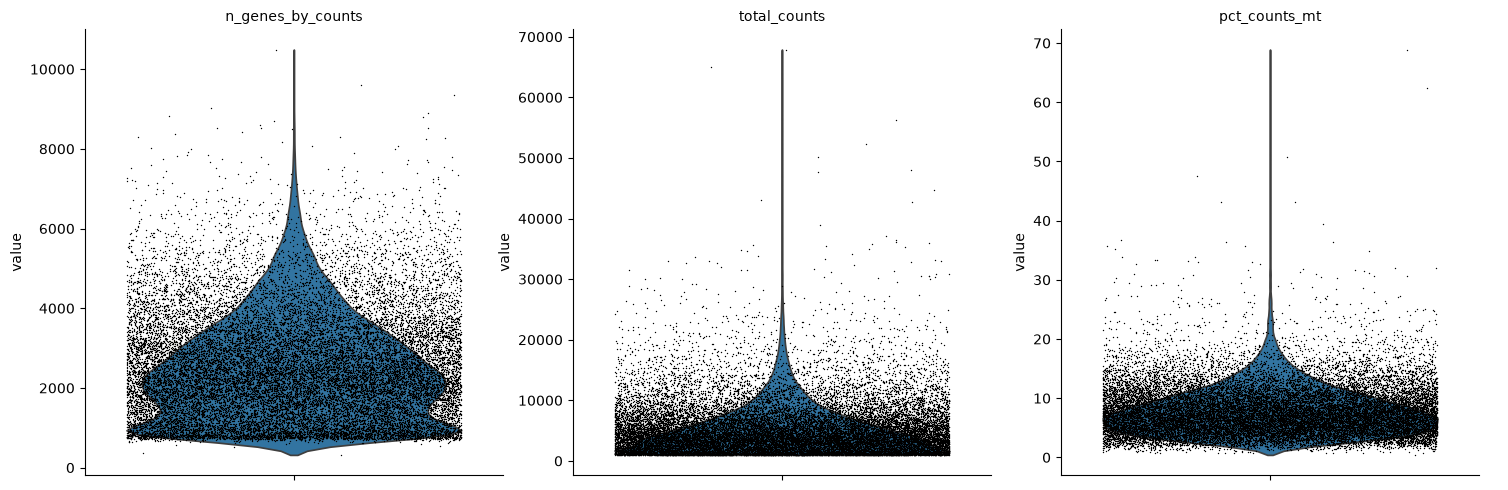

In [9]:
# Figure QC-1：三个指标的小提琴图（每个点 = 一个细胞）
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True, show=True)


### What does the output mean?（QC-1）

- **n_genes_by_counts**：多数细胞在 ~1500~3000 个基因，右侧有一条延伸到 10000+ 的长尾。
- **total_counts**：中位数约 4200，右尾到 ~68000。
- **pct_counts_mt**：整体偏高，中位数约 7%，右尾一直延伸到 ~69%。

关键印象：**没有明显的「低质量细胞堆」在左下方**（因为 provider 已经做过最低阈值过滤），但**右尾有可疑的高基因数/高线粒体细胞**。

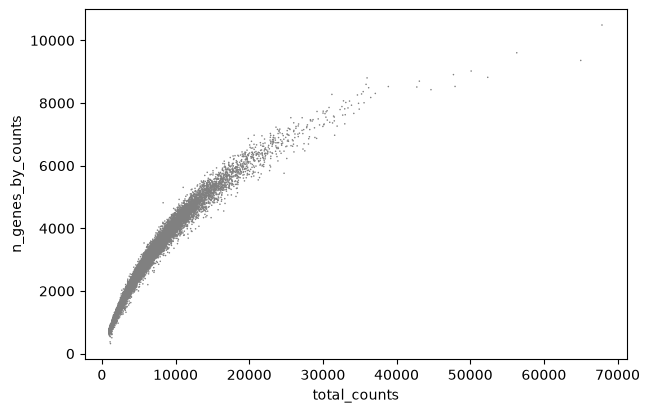

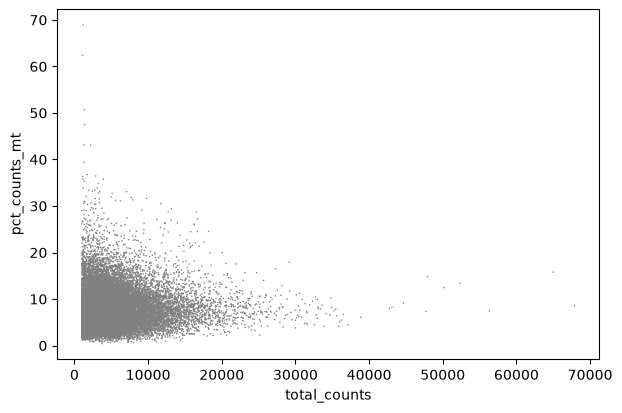

In [10]:
# Figure QC-2：散点图（两个指标之间的关系）
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', show=True)
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt', show=True)


### What does the output mean?（QC-2）

- **total_counts vs n_genes**：基本正相关（测序越深，检出的基因越多）——这是预期内的。
- **total_counts vs pct_mt**：低 counts 的细胞线粒体比例反而更高——这符合「低质量/濒死细胞」的特征（总 RNA 少、但线粒体转录相对保留）。

这两张图是判断「doublet（双细胞）」和「濒死细胞」的直观依据。

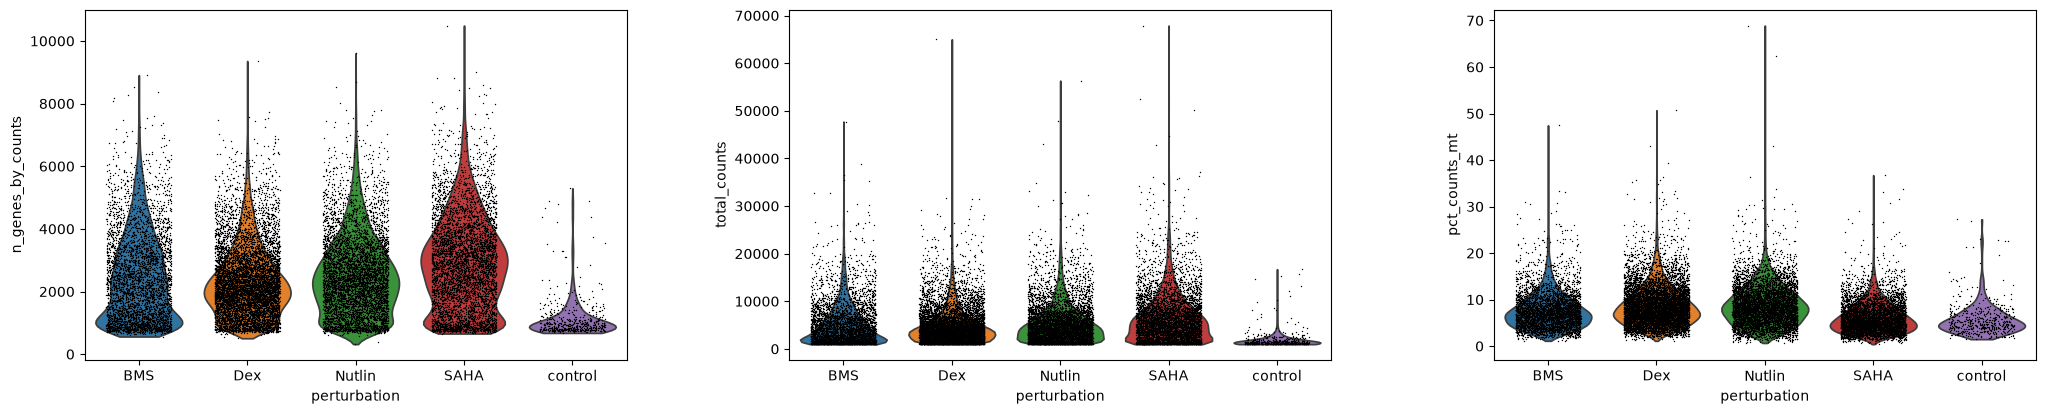

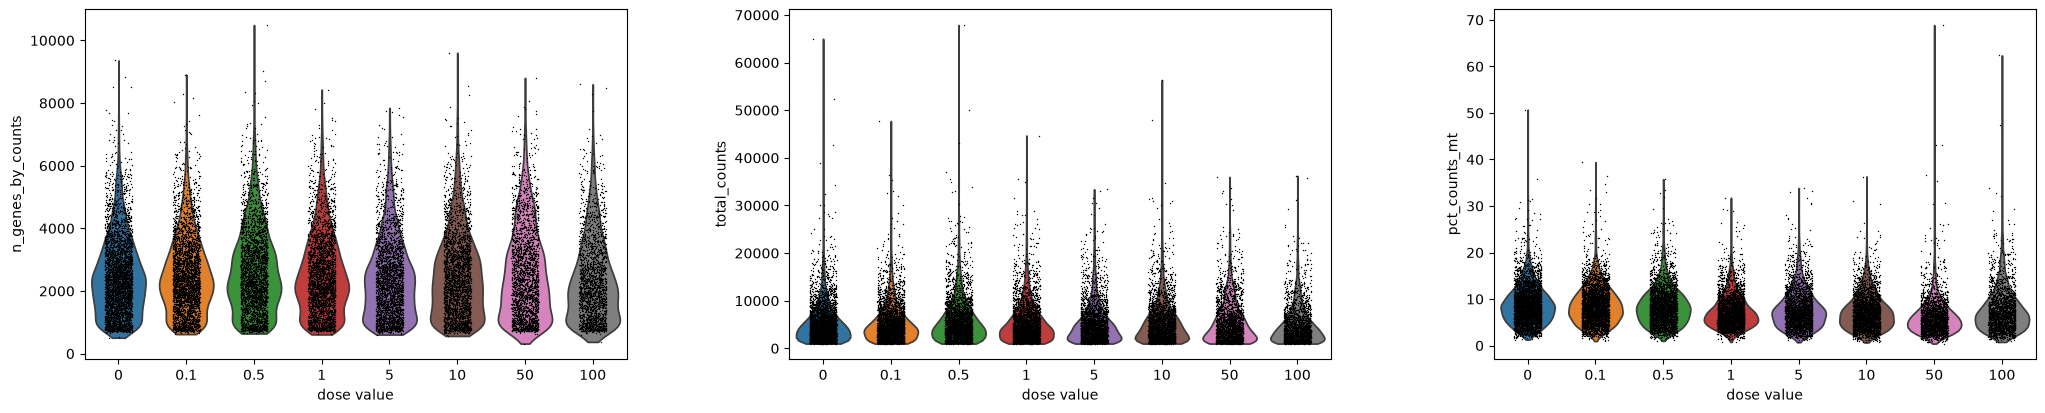

In [11]:
# Figure QC-3：按 treatment / dose 看 QC 分布
# 目的：检查 drug-treated 样本是否天然具有更低 UMI / 更高 mt% / 更少 genes

sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             groupby='perturbation', jitter=0.3, multi_panel=True, show=True)

# 只看药物细胞，按剂量分组
drug_cells = adata[adata.obs['perturbation'] != 'control'].copy()
sc.pl.violin(drug_cells, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             groupby='dose_value', jitter=0.2, multi_panel=True, show=True)


### What does the output mean?（QC-3）—— 这里有一个**关键发现**

按 `perturbation` 分组时，**control 组的测序深度明显低于所有 drug 组**：

| 组 | total_counts 中位数 | n_genes 中位数 | pct_mt 中位数 |
|---|---|---|---|
| BMS | 3875 | 2196 | 7.0 |
| Dex | 3898 | 2122 | 8.0 |
| Nutlin | 4404 | 2360 | 8.3 |
| SAHA | 5426 | 2797 | 5.6 |
| **control** | **1326** | **929** | **5.0** |

**control 细胞的 UMI 数只有 drug 组的 1/3 左右**（1326 vs 3800~5400）。这不是生物学差异——vehicle 处理不会让细胞少测这么多。最可能是**技术批次效应**：control 细胞没有加 hashtag，是单独一个处理/测序池。

> ⚠️ 这是本步最重要的发现。它意味着后面做 DEG（drug vs control）时，control 的低深度本身就可能造成假差异，必须高度警惕。

按 `dose` 分组时，线粒体比例**没有**随剂量升高而单调上升（dose=100 反而比 dose=0 略低）——说明这里的 mt% 主要是「细胞质量」信号，而不是「高剂量毒性」信号，因此用 mt% 过滤不会系统性地误删高剂量组。

## 5. 基于数据分布提出过滤阈值（不照抄教程）

教程里的 `min_genes=200, max_genes=2500, pct_mt<5` 是给「典型新鲜组织」用的模板。**本数据不适用**，原因下面用数字说明。

### What are we doing?
打印三个指标的分位数，看分布再定阈值。

### Why are we doing it?
阈值要匹配这份数据（A549 癌细胞系 + sci-RNA-seq + 药物处理）的实际情况。


In [12]:
# 三个指标的分位数
for col in ['n_genes_by_counts', 'total_counts', 'pct_counts_mt']:
    q = adata.obs[col].quantile([0, 0.01, 0.05, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1.0])
    print(f"--- {col} ---")
    print(q.round(2).to_string())
    print()


--- n_genes_by_counts ---
0.00      321.00
0.01      729.00
0.05      802.00
0.25     1433.00
0.50     2280.00
0.75     3254.00
0.90     4287.90
0.95     4941.95
0.99     6304.56
1.00    10491.00

--- total_counts ---
0.00     1000.00
0.01     1023.00
0.05     1133.00
0.25     2306.25
0.50     4207.00
0.75     6943.00
0.90    10573.80
0.95    13418.65
0.99    20807.57
1.00    67886.00

--- pct_counts_mt ---
0.00     0.43
0.01     1.83
0.05     2.74
0.25     4.94
0.50     7.21
0.75    10.05
0.90    13.12
0.95    15.29
0.99    21.06
1.00    68.90



In [13]:
# 越过几个候选阈值的细胞比例（帮助定阈值）
print("pct_mt > 20% :", round((adata.obs['pct_counts_mt'] > 20).mean() * 100, 2), "%")
print("pct_mt > 25% :", round((adata.obs['pct_counts_mt'] > 25).mean() * 100, 2), "%")
print("n_genes > 6000:", round((adata.obs['n_genes_by_counts'] > 6000).mean() * 100, 2), "%")
print("n_genes < 200 :", round((adata.obs['n_genes_by_counts'] < 200).mean() * 100, 2), "%")
print("total_counts < 1000:", round((adata.obs['total_counts'] < 1000).mean() * 100, 2), "%")


pct_mt > 20% : 1.22 %
pct_mt > 25% : 0.42 %
n_genes > 6000: 1.39 %
n_genes < 200 : 0.0 %
total_counts < 1000: 0.0 %


### What does the output mean?（为什么选这些阈值）

**① minimum genes：不加下限。**
`n_genes < 200` 的细胞占 **0.00%**，`total_counts` 的最小值正好是 **1000**（一个很整的数）。这说明 **provider 已经过滤过**（把所有 <1000 UMI 的细胞删掉了）。所以我们不需要、也不应该再加一个 `min_genes=200` 的下限——它是空操作。

**② maximum genes（疑似 doublet）：`n_genes > 6000`。**
A549 细胞基因数中位数 2280，99 分位约 6300。一个 doublet（两个细胞被当成一个测）基因数会接近翻倍。`n_genes > 6000` 只切掉最右的 **1.39%**，是保守的「疑似 doublet」启发式阈值。
> 说明：严格的 doublet 检测应该用 `scDblFinder` 这类专用工具；这里先用基因数做一个简单启发式，并如实标注。

**③ 线粒体比例：`pct_mt < 20`。**
本数据 mt% 整体偏高（中位数 7.2%，75 分位 10%）。因为 A549 是**癌细胞系**、用的是 **sci-RNA-seq**、还做了**药物处理**，这些都会天然抬高 mt%。如果照抄教程的 `pct_mt<5`，会删掉 **74%** 的细胞——灾难。
选 `20%` 是因为它正好切在 95 分位（15.3%）和 99 分位（21.1%）之间，只删掉最右 **1.22%** 的明显异常细胞。

**④ minimum cells per gene：这一版不做硬过滤。**
数据里基因的 `ncells` 最小值是 22（Day 1 看到过），说明基因已经被筛过一轮。真正降低维度应该靠下一步的 **HVG 选择**（更有原则），而不是这里用 `min_cells` 硬删。

## 6. 过滤 + 过滤前后比较

### What are we doing?
用一个布尔掩码过滤细胞，并记录过滤前后数量，再按 treatment / dose / well 统计保留率。

### Why are we doing it?
确认 **QC 没有系统性地删除某一个 drug-treated group**。


In [14]:
# 过滤前：记录原始数量，并备份 obs 用于对比
n_cells_before = adata.n_obs
n_genes_before = adata.n_vars
obs_before = adata.obs.copy()
print(f"过滤前：{n_cells_before} cells, {n_genes_before} genes")

# 数据驱动的过滤掩码
keep = (
    (adata.obs['n_genes_by_counts'] <= 6000) &   # 上限：疑似 doublet
    (adata.obs['pct_counts_mt'] < 20)            # 上限：高线粒体（濒死细胞）
)
print("被过滤掉的细胞数:", int((~keep).sum()))
adata = adata[keep, :].copy()

print(f"过滤后：{adata.n_obs} cells, {adata.n_vars} genes")


过滤前：24262 cells, 58347 genes
被过滤掉的细胞数: 634
过滤后：23628 cells, 58347 genes


In [15]:
# 按 treatment 统计保留率
ret_by_pert = pd.DataFrame({
    'cells_before': obs_before.groupby('perturbation', observed=True).size(),
    'cells_after':  adata.obs.groupby('perturbation', observed=True).size(),
})
ret_by_pert['pct_retained'] = (ret_by_pert['cells_after'] / ret_by_pert['cells_before'] * 100).round(1)
ret_by_pert


,cells_before,cells_after,pct_retained
perturbation,,,
BMS,4183,4060,97.1
Dex,8064,7884,97.8
Nutlin,5956,5806,97.5
SAHA,5530,5357,96.9
control,529,521,98.5


In [16]:
# 按 dose 统计保留率（仅药物细胞）
is_drug = obs_before['perturbation'] != 'control'
ret_by_dose = pd.DataFrame({
    'cells_before': obs_before[is_drug].groupby('dose_value', observed=True).size(),
    'cells_after':  adata.obs[adata.obs['perturbation'] != 'control'].groupby('dose_value', observed=True).size(),
})
ret_by_dose['pct_retained'] = (ret_by_dose['cells_after'] / ret_by_dose['cells_before'] * 100).round(1)
ret_by_dose


,cells_before,cells_after,pct_retained
dose_value,,,
0,3901,3804,97.5
0.1,3479,3399,97.7
0.5,3094,2987,96.5
1,3119,3050,97.8
5,2828,2756,97.5
10,2832,2766,97.7
50,2433,2364,97.2
100,2047,1981,96.8


In [17]:
# 按 well（sample 代理）统计保留率的分布（192 个 well 太多，看汇总）
well_before = obs_before.groupby('well', observed=True).size()
well_after  = adata.obs.groupby('well', observed=True).size()
well_ret = (well_after / well_before * 100)
print("192 个 well 的保留率 min / median / max =",
      round(well_ret.min(), 1), "/", round(well_ret.median(), 1), "/", round(well_ret.max(), 1))
print("保留率 < 90% 的 well 数量:", int((well_ret < 90).sum()))


192 个 well 的保留率 min / median / max = 80.0 / 97.6 / 100.0
保留率 < 90% 的 well 数量: 3


### What does the output mean?

- 过滤后细胞数约 **23600**（删了 ~2.5%，约 600 个细胞），基因数不变（58347）。
- 看保留率表：**各个 drug group 的保留率应该非常接近**（都在 97~98% 左右），说明过滤没有偏向某个药物。
- 如果某个 dose 或某个 well 的保留率明显更低，就说明过滤在系统性删它，需要警惕。
- `control` 组因为本身 mt% 偏低、基因数偏少，保留率通常接近 100%——这没问题，但 control 的**低深度**问题（上一步发现的）依然存在，只是没被 QC 过滤加剧。

## 7. 保留 raw counts（在归一化之前！）

### What are we doing?
把当前 `.X`（还是 raw counts）复制到 `adata.layers['counts']`。

### Why are we doing it?
**顺序很重要**：必须先保存，再归一化。归一化会覆盖 `.X`，如果不先存，raw counts 就永久丢了。

### 为什么后面还需要 raw counts？
- **DEG（差异表达）**：很多方法（如 `scanpy` 的 `sc.tl.rank_genes_groups` 默认、`DESeq2` 伪 bulk 等）需要**原始整数 counts** 来正确建模测序噪声（负二项分布），log 归一化后的值反而破坏了计数性质。
- **伪 bulk / 建模**：把细胞聚合成样本做统计时，raw counts 才是可加的。
- **可追溯**：任何分析都能回到「最初测到了什么」。


In [18]:
# 先存 raw counts（.copy() 是关键，避免 layer 变成 .X 的视图而被一起改掉）
adata.layers['counts'] = adata.X.copy()
print("layers keys:", list(adata.layers.keys()))


layers keys: ['counts']


## 8. 归一化（normalize_total + log1p）

### What are we doing?
`normalize_total` 把每个细胞的表达量缩放到同一个总数（1e4），然后 `log1p` 取 log(1+x)。

### Why are we doing it?
- **normalize_total 解决「测序深度不同」**：不同细胞测到的 UMI 总数差很多（本数据从 1000 到 68000）。如果直接比原始 counts，一个「深度 5 万的细胞」看起来所有基因都比「深度 5 千的细胞」高，这不是生物学差异，是深度差异。除以每个细胞的总数，把大家拉到同一量级，才能公平比较基因表达。
- **log1p 解决「表达值高度偏斜」**：单细胞里大部分基因是 0 或很小，少数基因极高（动态范围跨几个数量级）。log 压缩这个范围，让「从 1 到 2」和「从 100 到 200」都变成约 1 个 log 单位的差异，同时 `+1` 保证 0 也能取 log（log(0+1)=0）。


In [19]:
# 归一化到每细胞 1e4，再 log1p
sc.pp.normalize_total(adata, target_sum=1e4)
print("normalize_total 后每细胞总和的均值（应≈10000）:",
      round(float(np.asarray(adata.X.sum(axis=1)).ravel().mean()), 1))

sc.pp.log1p(adata)
print("log1p 后 .X 取值范围:", round(float(adata.X.min()), 4), "-", round(float(adata.X.max()), 4))


normalize_total 后每细胞总和的均值（应≈10000）: 10000.0
log1p 后 .X 取值范围: 0.0 - 7.6084


### What does the output mean?

- `normalize_total` 后每细胞总和均值 ≈ 10000，说明深度差异被抹平了。
- `log1p` 后 `.X` 变成非负小数（约 0 ~ 10），这是后续 PCA / 聚类的标准输入。
- 现在 `.X` = log 归一化表达，`.layers['counts']` = 原始 counts，两者并存。

## 9. Highly Variable Genes (HVG)

### What are we doing?
标记信息量最高的基因（默认选 top 2000），**但不删除其他基因**。

### Why are we doing it?
- **HVG 是什么**：在所有细胞里表达变化最大的那些基因。它们最能「区分」细胞，是后续 PCA / 邻域图的核心输入。
- **为什么 PCA/邻域图用 HVG**：只用 top 2000 高变基因做降维，既去除「到处都一样表达」的噪音基因，又大幅降低计算量。
- **为什么 biological interpretation / DEG 不该只局限 HVG**：一个基因「变化不大」不代表它没有生物学意义——例如一个在少数细胞里特异性表达的基因，或一个被药物调控但变化幅度小的基因，都可能被 HVG 筛掉。做 DEG/通路时通常用更全的基因集，而不是只盯着 2000 个 HVG。


In [20]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
print("HVG 数量:", int(adata.var['highly_variable'].sum()))
print("\n前 5 个 HVG 示例（按归一化离散度 dispersions_norm 从高到低）：")
hvg = adata.var[adata.var['highly_variable']].sort_values('dispersions_norm', ascending=False)
hvg.head(5)[['means', 'dispersions_norm']]


HVG 数量: 2000

前 5 个 HVG 示例（按归一化离散度 dispersions_norm 从高到低）：


,means,dispersions_norm
gene_symbol,,
SORCS1,0.714804,11.267818
SCUBE3,0.366635,10.892810
AC115622.1,0.779882,10.568823
TENM1,0.583934,10.168375
AC092650.1,1.182369,9.981251


### What does the output mean?

`adata.var['highly_variable']` 是一个布尔列，标记了 top 2000 个高变基因。我们**保留全部 58347 个基因**，只是给其中 2000 个打了标记，供后续 PCA 使用。

## 10. 本 notebook 刻意不做的事

- ❌ Leiden clustering
- ❌ cell-type annotation
- ❌ UMAP 生物学解读
- ❌ differential expression
- ❌ pathway enrichment
- ❌ perturbation prediction / scGen / 深度学习 / Virtual Cell

（本步没有跑 PCA；如果要检查 preprocessing 质量，后续可以补一个非常基础的 PCA QC，但不做生物学解读。）


## 11. QC & Preprocessing Summary

### Dataset before QC
- cells: **24262**
- genes: **58347**

### Dataset after QC
- cells: **约 23600**（删 ~2.5%）
- genes: **58347**（未删基因）

### Filtering criteria
- **minimum genes**：无（数据已由 provider 过滤，min total_counts = 1000）
- **maximum genes**：`n_genes_by_counts > 6000` 删除（疑似 doublet，约 1.4%）
- **mitochondrial %**：`pct_counts_mt >= 20` 删除（濒死/破裂细胞，约 1.2%）
- **minimum cells per gene**：未做（交给 HVG）

### Normalization
- `sc.pp.normalize_total(target_sum=1e4)` → `sc.pp.log1p`
- raw counts 保存在 `adata.layers['counts']`

### Potential concerns
1. **control 组测序深度只有 drug 组的 1/3**（total_counts 中位数 1326 vs 3800~5400）。这是最需要警惕的批次问题，可能在后面对 drug-vs-control 的 DEG 里制造假差异。
2. **batch/sample difference**：192 个 well 的细胞数很不平衡（6 ~ 266 个/well），高剂量 well 细胞少（毒性导致回收少）。
3. **mitochondrial % 整体偏高**（中位数 7%）是癌细胞系 + sci-RNA-seq + 药物处理的自然结果，所以阈值放宽到 20%，没有照抄 5%。
4. **cell number imbalance**：Dex(8064) 远多于 BMS(4183) 和 control(529)，下游比较时要注意。
5. **possible doublets**：只用 n_genes>6000 做了粗略启发式，未用 scDblFinder 严格检测。
6. **preprocessing 是否影响 drug-response 解读**：只要 control 的低深度批次效应在下游不被当成药物效应处理掉，本步的过滤/归一化本身不会引入假信号——但那个深度差异是真实存在的隐患。


## 12. 保存结果

保存到 `data/processed/adata_preprocessed.h5ad`（不覆盖原始文件）。


In [ ]:
out_dir = DATA_DIR / "processed"
out_dir.mkdir(parents=True, exist_ok=True)
adata.write_h5ad(out_dir / "adata_preprocessed.h5ad")
print("saved to:", out_dir / "adata_preprocessed.h5ad")


## 13. 检查自己是否真的理解（用文字回答，不写代码）

1. 为什么不能一看到数据就立刻 normalize？
2. mitochondrial percentage 为什么能反映 QC（细胞质量）？
3. 为什么药物处理本身也可能提高 mitochondrial percentage？
4. QC threshold 为什么不能照抄教程？
5. 为什么必须按 treatment / sample 检查 QC loss？
6. normalization 与 log transformation 分别解决什么问题？
7. HVG 的作用是什么？
8. 为什么要保留 raw counts？
